# Project - Problem 2

Implementation of VO

## Import Modules

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
import scipy.signal
import scipy.linalg
import mae6292.tools as mae6292
import importlib
import scipy.spatial.distance


In [ ]:
import mae6292.tools as mae6292
from mae6292.imshow import cv2_imshow
from mae6292.tools import (
    harris_corner, select_keypoints,
    KLT, hom, deh,
    triangulation_robust,
    VO_bootstrap, VO_localization_mapping,
    state, candidate,
    draw_frame
)

Calibration image: 3718x2748
Saved calib_corners.png — check corners look correct before continuing!

── Calibration Result ───────────────────────────────────
RMS reprojection error : 0.8971 px

K =
[[1.59615511e+03 0.00000000e+00 2.11021817e+03]
 [0.00000000e+00 1.52812475e+03 1.52978177e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion coefficients: [-0.00959864  0.01714987  0.00052183 -0.00173835 -0.01016092]

Camera origin in world frame:
[ 4.80720527  1.60711347 -3.23930339]


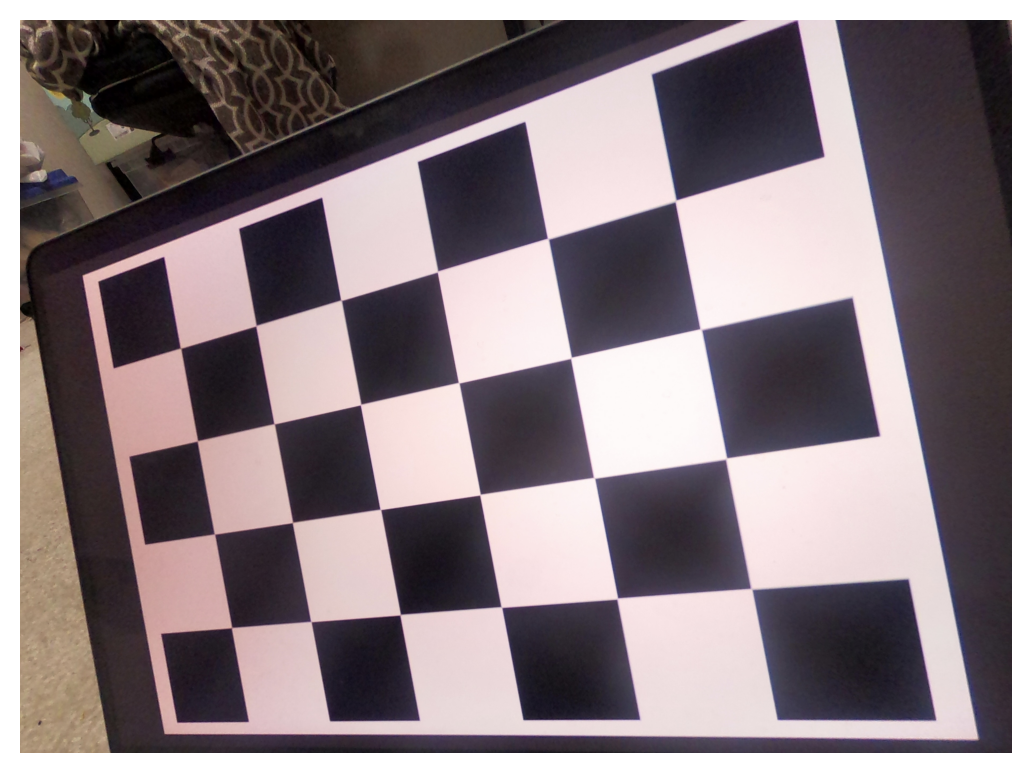

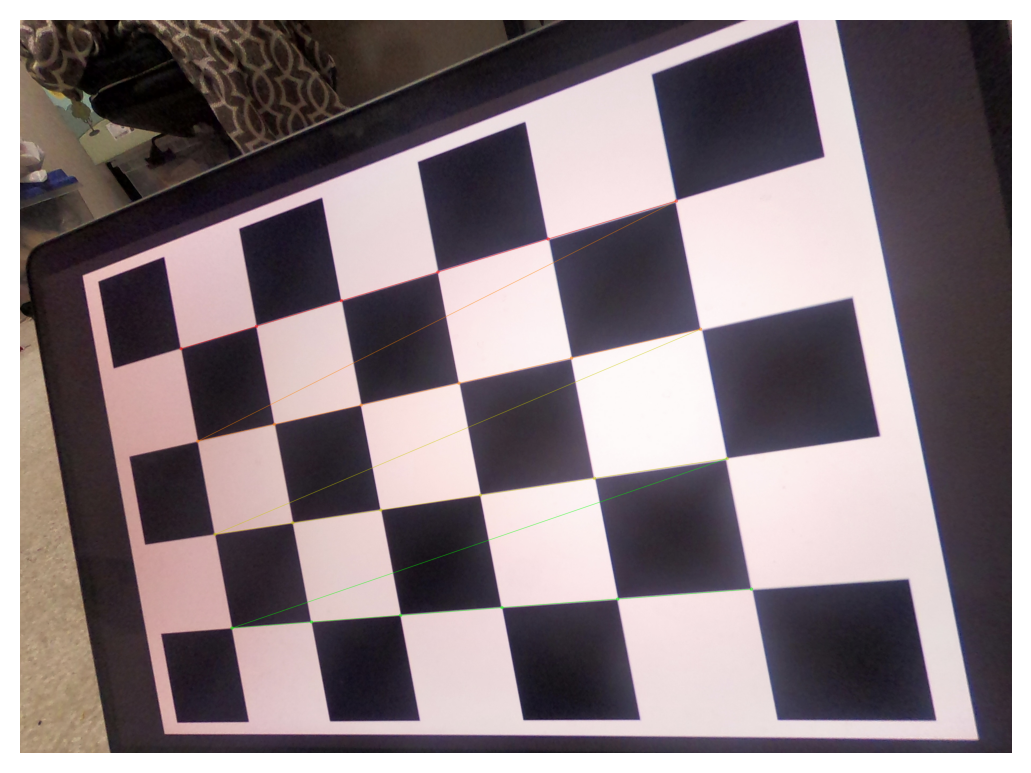

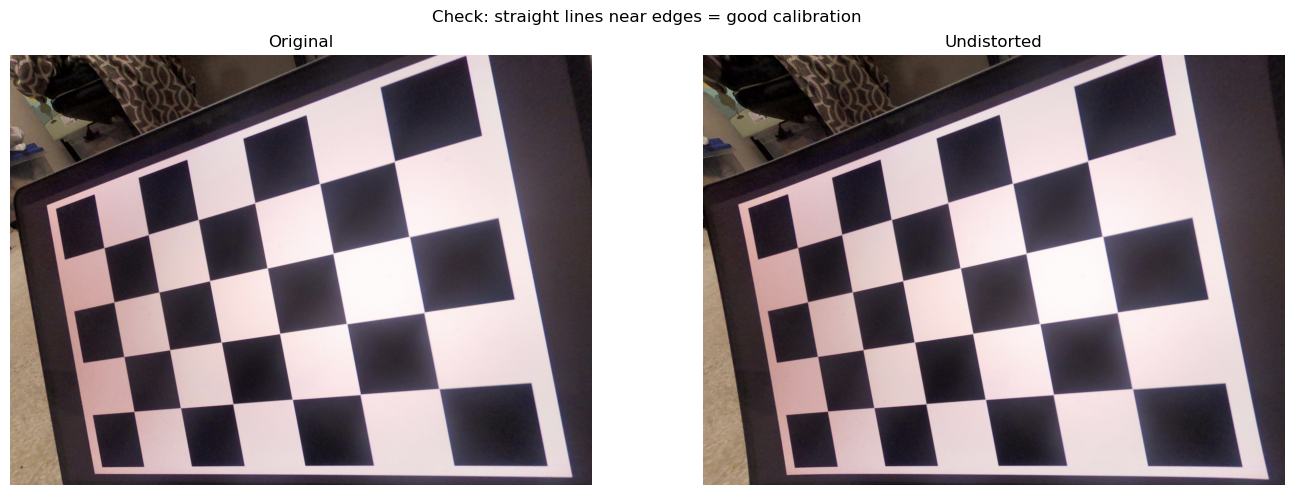


Saved K.txt and dist_coeffs.txt


In [ ]:
%matplotlib inline
# PART 1 — CAMERA CALIBRATION  
# ═══════════════════════════════════════════════════════════════

# Config 
CALIB_IMAGE   = 'checkerboard.png'   
CHECKER       = (6, 4)               
CHECKER_WIDTH = 1                    

# Load image 
img_calib      = cv2.imread(CALIB_IMAGE)
img_calib_gray = cv2.cvtColor(img_calib, cv2.COLOR_BGR2GRAY)
assert img_calib is not None, f"Could not read calibration image: {CALIB_IMAGE}"
print(f"Calibration image: {img_calib.shape[1]}x{img_calib.shape[0]}")
cv2_imshow(img_calib)

ret, corners = cv2.findChessboardCorners(
    img_calib_gray,
    CHECKER,
    cv2.CALIB_CB_ADAPTIVE_THRESH +
    cv2.CALIB_CB_NORMALIZE_IMAGE +
    cv2.CALIB_CB_FAST_CHECK
)
assert ret, (
    "Checkerboard not detected!\n"
    "• Make sure the upper-left square is BLACK in your photo\n"
    "• Verify CHECKER = (inner_cols, inner_rows) — for a 6x4 board that is (5,3)\n"
    "• Ensure the full board is visible and well-lit"
)

# Refine to sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
corners_refined = cv2.cornerSubPix(
    img_calib_gray, corners, (11, 11), (-1, -1), criteria
)

# Draw and save corners
img_corners = img_calib.copy()
cv2.drawChessboardCorners(img_corners, CHECKER, corners_refined, ret)
cv2_imshow(img_corners)
cv2.imwrite('calib_corners.png', img_corners)
print("Saved calib_corners.png — check corners look correct before continuing!")

# Build 3-D world points 
# Origin = upper-left inner corner, x→right, y→down, z into board
obj_points_single = np.zeros((CHECKER[0] * CHECKER[1], 1, 3), np.float32)
obj_points_single[:, 0, :2] = (
    np.mgrid[0:CHECKER[0], 0:CHECKER[1]].T.reshape(-1, 2) * CHECKER_WIDTH
)

obj_points = [obj_points_single]   
img_points = [corners_refined]
h, w = img_calib_gray.shape

#  Calibrate 
retval, K, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    obj_points, img_points, (w, h), None, None
)

print(f"\n── Calibration Result ───────────────────────────────────")
print(f"RMS reprojection error : {retval:.4f} px")
print(f"\nK =\n{K}")
print(f"\nDistortion coefficients: {dist_coeffs.flatten()}")

# Camera origin in world frame 
R_calib, _ = cv2.Rodrigues(rvecs[0])
t_calib     = tvecs[0]
camera_origin_world = -R_calib.T @ t_calib
print(f"\nCamera origin in world frame:\n{camera_origin_world.flatten()}")

#  Undistortion check 
img_undist = cv2.undistort(img_calib, K, dist_coeffs)
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(img_calib,  cv2.COLOR_BGR2RGB)); axes[0].set_title('Original');    axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_undist, cv2.COLOR_BGR2RGB)); axes[1].set_title('Undistorted'); axes[1].axis('off')
plt.suptitle('Check: straight lines near edges = good calibration')
plt.tight_layout(); plt.savefig('calib_undistortion.png', dpi=120); plt.show()

# Save K 
np.savetxt('K.txt', K)
np.savetxt('dist_coeffs.txt', dist_coeffs)
print("\nSaved K.txt and dist_coeffs.txt")


In [ ]:

# VISUAL ODOMETRY 
# ═══════════════════════════════════════════════════════════════

# Config 
VIDEO_PATH='my_video.mp4'
FRAME_STEP=2
BOOT_FRAME=6
MAX_FRAMES=4700

param={
    'W_harris_patch':4,
    'kappa_harris':0.08,
    'N_keypoint':2000,
    'W_nms':8,
    'W_KLT':4,
    'tol_KLT_bidir':1.5,
    'tol_E':1.0,
    'tol_E_RANSAC_prob':0.99,
    'tol_TRI_mu':5e-3,
    'tol_TRI_rep':2.0,
    'tol_keypoints_new':15,
}

# ── Load calibration 
dist_coeffs=np.loadtxt('dist_coeffs.txt')

print('K=\n',K)

# ── Video Reader 
cap=cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(),f"Cannot open {VIDEO_PATH}"

total_frames=int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps_vid=cap.get(cv2.CAP_PROP_FPS)
W_vid=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_vid=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"\nVideo: {total_frames} frames | {fps_vid:.1f} fps | {W_vid}x{H_vid}")

def read_frame_at(cap,frame_number):

    cap.set(cv2.CAP_PROP_POS_FRAMES,frame_number)

    ret,frame=cap.read()

    if not ret or frame is None:
        return None,None

    frame=cv2.undistort(frame,K,dist_coeffs)
    frame = cv2.resize(frame, (1241, 376))

    gray=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
    rgb=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)

    return gray,rgb

def read_next_frame(cap):

    ret,frame=cap.read()

    if not ret or frame is None:
        return None,None

    frame=cv2.undistort(frame,K,dist_coeffs)
    frame = cv2.resize(frame, (1241, 376))

    gray=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
    rgb=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)

    return gray,rgb

# ── Bootstrap 
img0_gray,img0_rgb=read_frame_at(cap,0)
img_boot_gray,_=read_frame_at(cap,BOOT_FRAME*FRAME_STEP)

assert img0_gray is not None
assert img_boot_gray is not None

keypoints_boot,p_W_boot,R_boot,T_boot=VO_bootstrap(
    img0_gray,
    img_boot_gray,
    K,
    param,
    display=True
)

print(f"\nBootstrap landmarks: {p_W_boot.shape[1]}")

# ── Initial State 
T_W_boot=-R_boot.T@T_boot

S=state(
    keypoints=keypoints_boot,
    p_W=p_W_boot,
    T_W_history=[np.zeros((3,1)),T_W_boot]
)

C=candidate(
    keypoints=[],
    keypoints_org=[],
    R_org=[],
    T_org=[]
)

# VISUALIZATION SETTINGS
# ═════════════════════════════════════════════
MAP_SIZE=700
MAP_SCALE=12
OUT_W=1241
OUT_H=376


# IMAGE PANEL
# ─────────────────────────────────────────────
prev_vis_pts=None

def render_img_panel(img_rgb,S_cur,C_cur,i_frame):
    global prev_vis_pts
    vis=img_rgb.copy()
    cur_pts=[(int(u),int(v)) for (v,u) in S_cur.keypoints]
    # motion tracks
    if prev_vis_pts is not None:
        n=min(len(prev_vis_pts),len(cur_pts))
        for i in range(n):
            p1,p2=prev_vis_pts[i],cur_pts[i]
            dx=p2[0]-p1[0]
            dy=p2[1]-p1[1]
            if dx*dx+dy*dy<400:
                cv2.line(
                    vis,
                    p1,
                    p2,
                    (255,0,0),
                    1,
                    cv2.LINE_AA
                )

    prev_vis_pts=cur_pts

    # tracked points
    for (v,u) in S_cur.keypoints:
        cv2.circle(
            vis,
            (int(u),int(v)),
            2,
            (0,0,255),
            -1,
            cv2.LINE_AA
        )

    # candidate points
    for (v,u) in C_cur.keypoints:
        cv2.circle(
            vis,
            (int(u),int(v)),
            1,
            (255,0,0),
            -1,
            cv2.LINE_AA
        )

    cv2.putText(
        vis,
        f'FRAME {i_frame}',
        (20,35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255,255,255),
        2,
        cv2.LINE_AA
    )

    return vis

# 3D TRAJECTORY VIEW
# ─────────────────────────────────────────────

def render_3d_view(T_W_history, p_W, angle=0):
    canvas = np.zeros((MAP_SIZE, MAP_SIZE, 3), dtype=np.uint8)
    traj = np.array([t.flatten() for t in T_W_history])

    # camera rotation around scene
    theta = np.radians(angle)

    Ry = np.array([
        [ np.cos(theta), 0, np.sin(theta)],
        [ 0,             1, 0            ],
        [-np.sin(theta), 0, np.cos(theta)]
    ])

    # rotate landmarks
    P = Ry @ p_W

    # rotate trajectory
    traj_rot = (Ry @ traj.T).T

    # fake perspective projection
    def project(pt):
        x, y, z = pt
        z += 40
        if z <= 1:
            return None

        f = 220 / z

        u = int(MAP_SIZE/2 + x*f)
        v = int(MAP_SIZE/2 - y*f)

        return (u, v)

    # draw landmarks
    step = max(1, P.shape[1] // 3000)

    for i in range(0, P.shape[1], step):
        p = project(P[:, i])
        if p is None:
            continue

        u, v = p

        if 0 <= u < MAP_SIZE and 0 <= v < MAP_SIZE:
            depth = P[2, i]
            brightness = max(50, 255 - int(depth * 3))
            cv2.circle(canvas,(u, v),1,(brightness, brightness, brightness),-1)

    # draw trajectory
    for i in range(1, len(traj_rot)):
        p1 = project(traj_rot[i-1])
        p2 = project(traj_rot[i])

        if p1 is None or p2 is None:
            continue
        cv2.line(canvas,p1,p2,(0,255,0),2,cv2.LINE_AA)

    # current camera position
    p = project(traj_rot[-1])

    if p is not None:

        cv2.circle(canvas,p,6,(0,0,255),-1)

    cv2.putText(canvas,'3D VIEW',(15,30),cv2.FONT_HERSHEY_SIMPLEX,0.8,(255,255,255),2)

    return canvas

# VIDEO WRITER
# ═════════════════════════════════════════════

probe_vis=render_img_panel(img0_rgb,S,C,0)
fourcc=cv2.VideoWriter_fourcc(*'mp4v')

writer=cv2.VideoWriter(
    'prob2.mp4',
    fourcc,
    30,
    (OUT_W,OUT_H)
)

def write_video_frame(vis_rgb,map_bgr):
    vis_bgr=cv2.cvtColor(vis_rgb,cv2.COLOR_RGB2BGR)

    cam_w=int(OUT_W*0.68)
    map_w=OUT_W-cam_w

    vis_resized=cv2.resize(vis_bgr,(cam_w,OUT_H))
    map_resized=cv2.resize(map_bgr,(map_w,OUT_H))

    canvas=np.hstack([vis_resized,map_resized])

    writer.write(canvas)

K=
 [[1.59615511e+03 0.00000000e+00 2.11021817e+03]
 [0.00000000e+00 1.52812475e+03 1.52978177e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Video: 4799 frames | 30.0 fps | 1440x1080

Bootstrap landmarks: 638
S_pre= 585 , KLT_matched= 576 , PnP_inliers= 575 , S_new =  1241
C_pre= 1115 , KLT_matched= 959 , TRI_inliers= 666 , C_new =  347
S_pre= 1241 , KLT_matched= 1190 , PnP_inliers= 1187 , S_new =  1291
C_pre= 347 , KLT_matched= 317 , TRI_inliers= 104 , C_new =  257
S_pre= 1291 , KLT_matched= 1245 , PnP_inliers= 1228 , S_new =  1269
C_pre= 257 , KLT_matched= 234 , TRI_inliers= 41 , C_new =  231
Frame   10 | LM:1269 | POS=(-0.26,-0.25,+0.28)
S_pre= 1269 , KLT_matched= 1230 , PnP_inliers= 1199 , S_new =  1230
C_pre= 231 , KLT_matched= 211 , TRI_inliers= 31 , C_new =  243
S_pre= 1230 , KLT_matched= 1161 , PnP_inliers= 1132 , S_new =  1197
C_pre= 243 , KLT_matched= 213 , TRI_inliers= 65 , C_new =  249
S_pre= 1197 , KLT_matched= 1152 , PnP_inliers= 1136 , S_new =  1228
C_pre= 249 ,

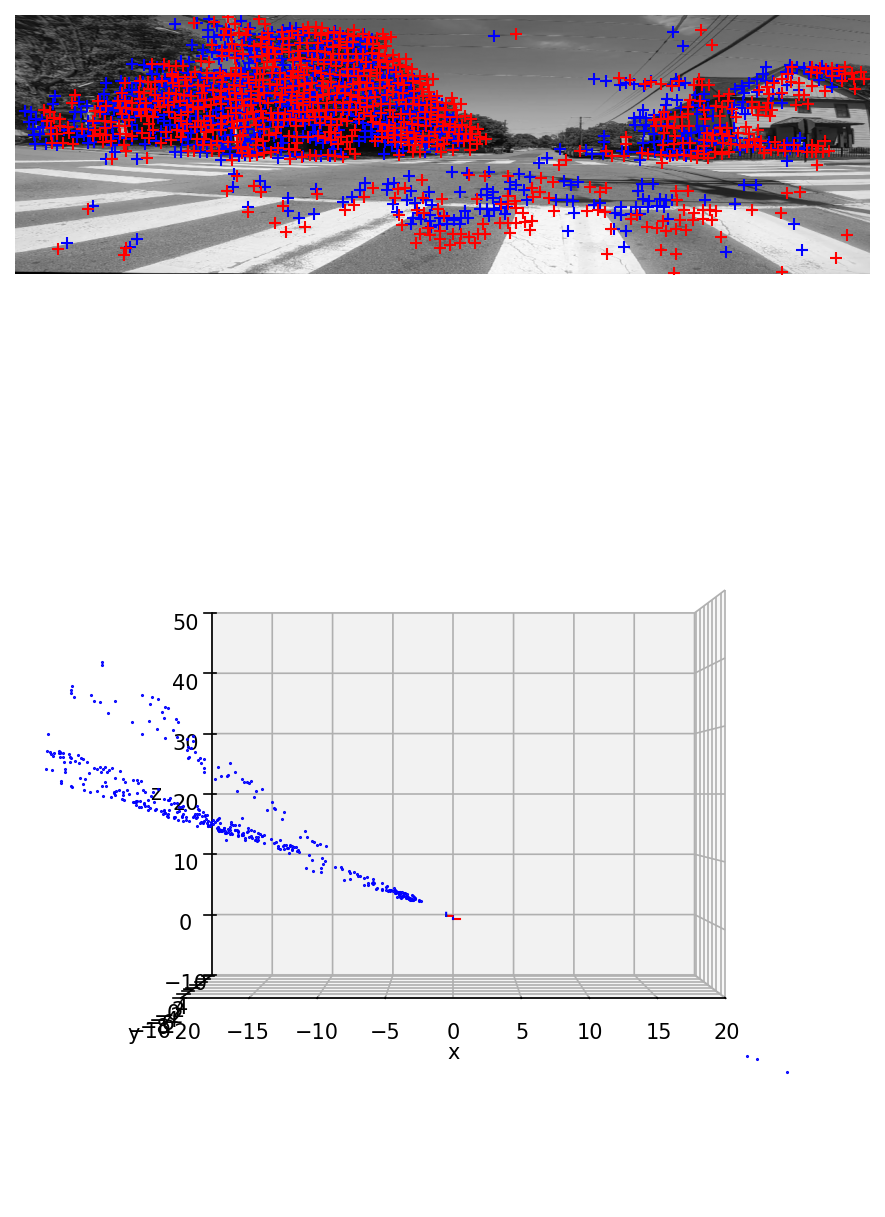

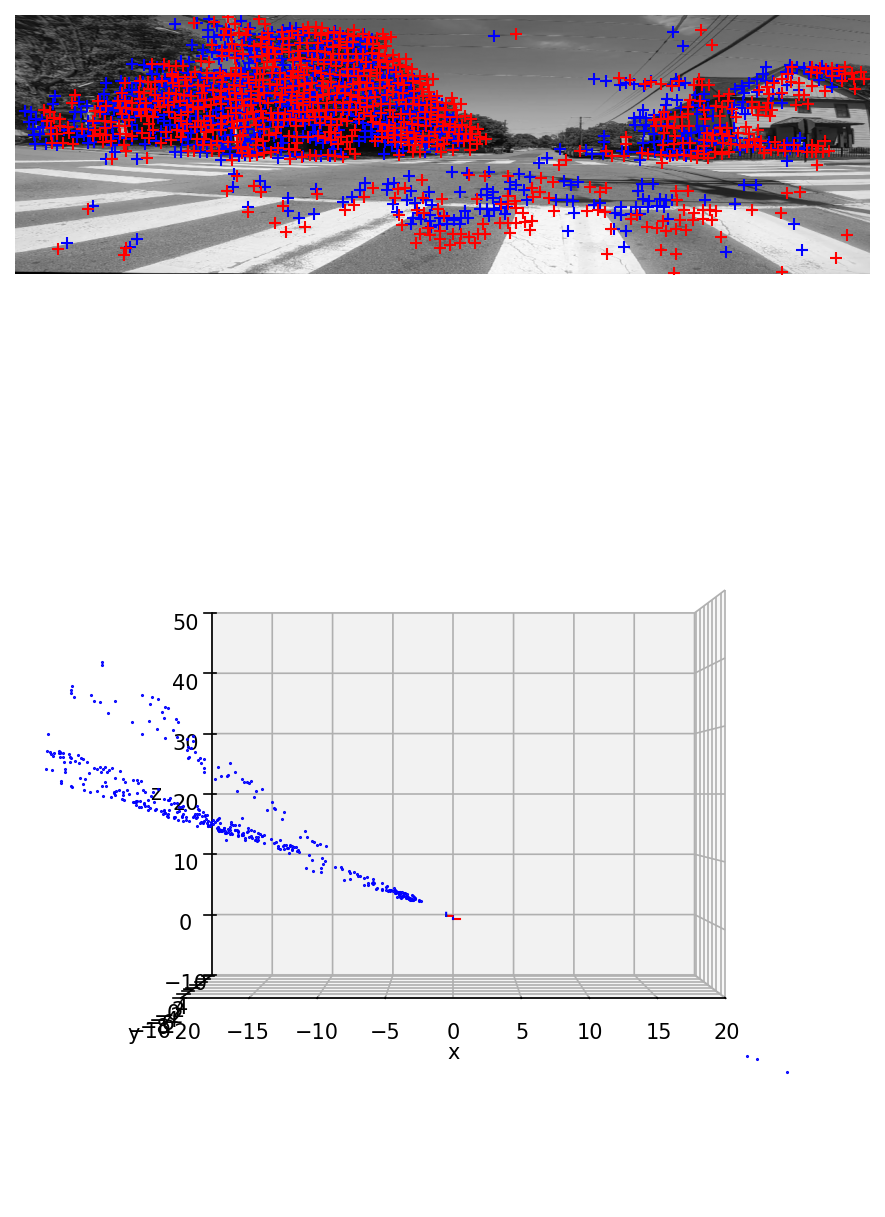

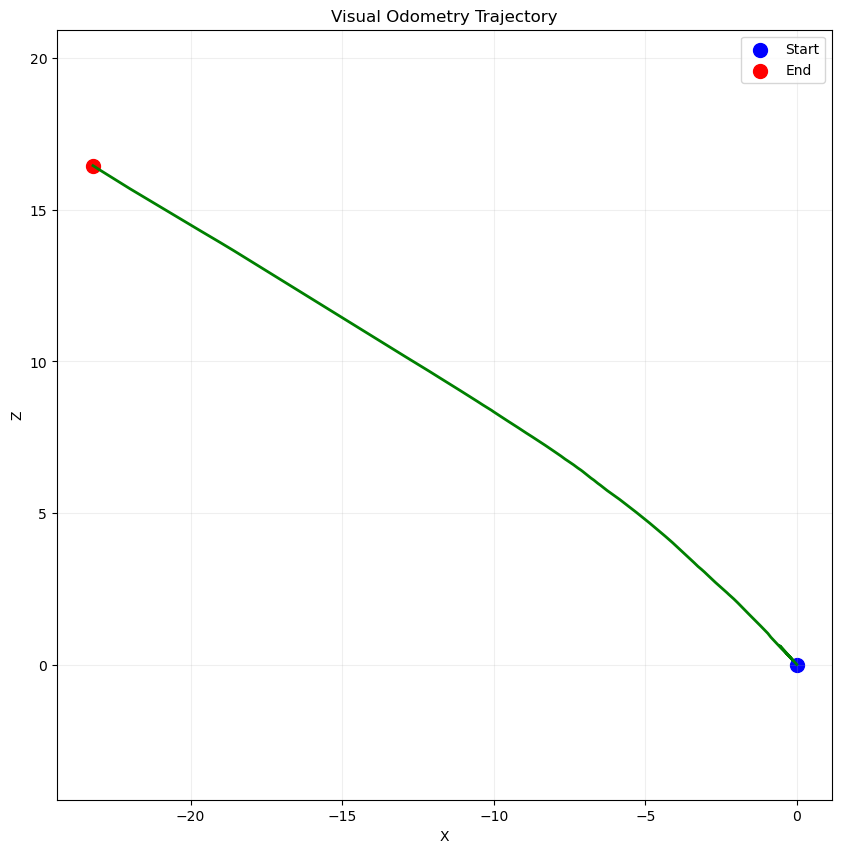

Saved prob2_map.png


In [ ]:
# MAIN VO LOOP
# ═════════════════════════════════════════════

cap.set(
    cv2.CAP_PROP_POS_FRAMES,
    (BOOT_FRAME+1)*FRAME_STEP
)

img_pre=img_boot_gray
n_failed=0
i_frame=BOOT_FRAME+1

while i_frame<MAX_FRAMES:
    img_cur,img_cur_rgb=read_next_frame(cap)

    if img_cur is None:
        print("End of video.")
        break

    R,T,S_new,C_new,_=VO_localization_mapping(i_frame,img_cur,img_cur_rgb,img_pre,S,C,K,param,display_process=False)

   
# POSE RECOVERY 
# ─────────────────────────────────────────────

    if R is None or T is None or np.allclose(R, 0):
        print(f"[ERROR] Frame {i_frame}: pose failed")

    # keep previous state completely
        S_new = S
        C_new = C

        n_failed += 1

    else:
        n_failed = 0

    if n_failed>10:
        print("[FATAL] Too many failures.")
        break

    S,C=S_new,C_new

    vis=render_img_panel(img_cur_rgb,S,C,i_frame)
    mmap = render_3d_view(
    S.T_W_history,
    S.p_W,
    angle=i_frame*0.3
)

    write_video_frame(vis,mmap)

    if i_frame%10==0:

        T_W=S.T_W_history[-1].flatten()

        print(
            f"Frame {i_frame:4d} | "
            f"LM:{S.p_W.shape[1]:4d} | "
            f"POS=({T_W[0]:+.2f},"
            f"{T_W[1]:+.2f},"
            f"{T_W[2]:+.2f})"
        )

    img_pre=img_cur
    i_frame+=1

# ── Cleanup 
cap.release()
writer.release()

print("\nSaved prob2.mp4")


# FINAL TRAJECTORY PLOT
# ═════════════════════════════════════════════

traj = np.array([
    np.asarray(t).reshape(3)
    for t in S.T_W_history
])

# remove duplicated poses
if len(traj) > 1:

    diff = np.linalg.norm(
        np.diff(traj, axis=0),
        axis=1
    )

    keep = np.insert(diff > 1e-4, 0, True)

    traj = traj[keep]
lm=S.p_W

plt.figure(figsize=(10,10))

plt.scatter(lm[0,:],lm[2,:],s=1,c='gray',alpha=0.3)

plt.plot(traj[:,0],traj[:,2],'g-',linewidth=2)

plt.scatter(traj[0,0],traj[0,2],s=100,c='blue',label='Start')
plt.scatter(traj[-1,0],traj[-1,2],s=100,c='red',label='End')

plt.xlabel('X')
plt.ylabel('Z')

plt.title('Visual Odometry Trajectory')

plt.axis('equal')
plt.grid(alpha=0.2)
plt.legend()

plt.savefig('prob2_map.png',dpi=200)

plt.show()

print("Saved prob2_map.png")

Link to footage original used and prob2.mp4 (too big for github): https://drive.google.com/drive/folders/1ASt3Q3KzC3o9st2V3mZo-P3j-dGyNR6h?usp=sharing
